In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file = "data/elektrik_veri_hashed.xlsx"

xls = pd.ExcelFile(file)

print(xls.sheet_names)

['Tahsilat', 'Tahsilat 1', 'Tahakkuk', 'Tahakkuk 1', 'Tahakkuk 2']


In [4]:
df_tahsilat = pd.read_excel(file, sheet_name="Tahsilat")
df_tahsilat1 = pd.read_excel(file, sheet_name="Tahsilat 1")

df_hamamozu = pd.read_excel(file, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(file, sheet_name="Tahakkuk 1")
df_goyuncek = pd.read_excel(file, sheet_name="Tahakkuk 2")

In [5]:
df_all = pd.concat([df_hamamozu, df_gumushacikoy, df_goyuncek])

print(df_all.isnull().sum())

df_all = df_all[df_all['kwh'] >= 0]

df_all['fatura_tarihi'] = pd.to_datetime(df_all['fatura_tarihi'])

il                   0
ilce                 0
sozlesme_hesap_no    0
mali_yil_donem       0
fatura_tarihi        0
kayit_tarihi         0
vade_tarihi          0
hesap_sinifi         0
Hesap Sınıfı         0
kwh                  0
dtype: int64


In [6]:
df_hamamozu.head()

,il,ilce,sozlesme_hesap_no,mali_yil_donem,fatura_tarihi,kayit_tarihi,vade_tarihi,hesap_sinifi,Hesap Sınıfı,kwh
0,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-01-12,2023-03-06,2023-01-23,M001,Mesken,1.79
1,AMASYA,HAMAMÖZÜ,917576806,2023-01-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,2.60
2,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-02-09,2023-05-11,2023-02-20,M001,Mesken,1.23
3,AMASYA,HAMAMÖZÜ,917576806,2023-02-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,2.56
4,AMASYA,HAMAMÖZÜ,917576806,2023-03-01,2023-03-10,2023-05-11,2023-03-20,M001,Mesken,1.35


In [7]:
df_hamamozu.info()

<class 'pandas.DataFrame'>
RangeIndex: 124818 entries, 0 to 124817
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   il                 124818 non-null  str    
 1   ilce               124818 non-null  str    
 2   sozlesme_hesap_no  124818 non-null  int64  
 3   mali_yil_donem     124818 non-null  str    
 4   fatura_tarihi      124818 non-null  str    
 5   kayit_tarihi       124818 non-null  str    
 6   vade_tarihi        124818 non-null  str    
 7   hesap_sinifi       124818 non-null  object 
 8   Hesap Sınıfı       124818 non-null  str    
 9   kwh                124818 non-null  float64
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 9.5+ MB


In [8]:
df_hamamozu.describe()

,sozlesme_hesap_no,kwh
count,1.248180e+05,124818.000000
mean,5.044916e+09,70.874619
std,2.874544e+09,389.217875
min,2.903944e+06,-1242.990000
25%,2.577471e+09,15.490000
50%,5.027442e+09,40.560000
75%,7.594090e+09,70.430000
max,9.991894e+09,25941.600000


In [9]:
print("Hamamözü müşteri:", df_hamamozu["sozlesme_hesap_no"].nunique())
print("Gümüşhacıköy müşteri:", df_gumushacikoy["sozlesme_hesap_no"].nunique())
print("Göynücek müşteri:", df_goyuncek["sozlesme_hesap_no"].nunique())

Hamamözü müşteri: 2981
Gümüşhacıköy müşteri: 18190
Göynücek müşteri: 7128


In [10]:
df_all = pd.concat([df_hamamozu, df_gumushacikoy, df_goyuncek])

print("Toplam kayıt:", len(df_all))

Toplam kayıt: 1185698


In [11]:
df_all.isna().sum()

il                   0
ilce                 0
sozlesme_hesap_no    0
mali_yil_donem       0
fatura_tarihi        0
kayit_tarihi         0
vade_tarihi          0
hesap_sinifi         0
Hesap Sınıfı         0
kwh                  0
dtype: int64

In [12]:
(df_all["kwh"] < 0).sum()

np.int64(151)

In [13]:
df_all.groupby("Hesap Sınıfı")["kwh"].agg(["mean","median","std"])

,mean,median,std
Hesap Sınıfı,,,
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ,688.441598,23.860,3911.912974
Aritma Tesisleri,16594.174857,16186.910,11656.705924
Balıkçılık ve Su Ürünleri Yetiştiriciliğ,85.358306,79.375,42.120066
Belediye,600.581235,78.270,3350.978976
Belediye Park Bahçe Aydınlatma,31.951003,18.390,38.472449
"Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)",29.965663,15.760,41.331395
Büyükbaş-Küçükbaş Hayvancılık,116.848021,24.110,408.549664
Cemevleri,10.713755,5.625,16.453958
Diyanet Kuran Kursu,167.135000,22.115,526.354274


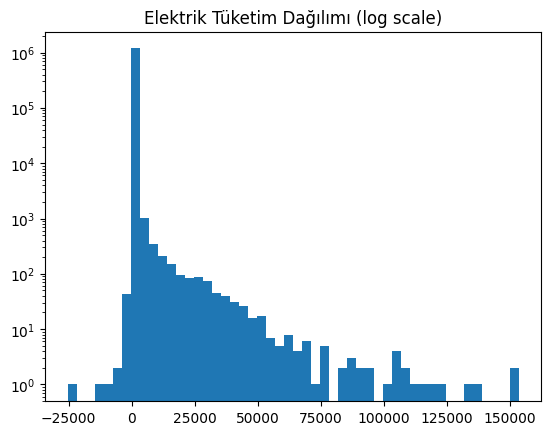

In [14]:
plt.hist(df_all["kwh"], bins=50)
plt.yscale("log")

plt.title("Elektrik Tüketim Dağılımı (log scale)")
plt.show()

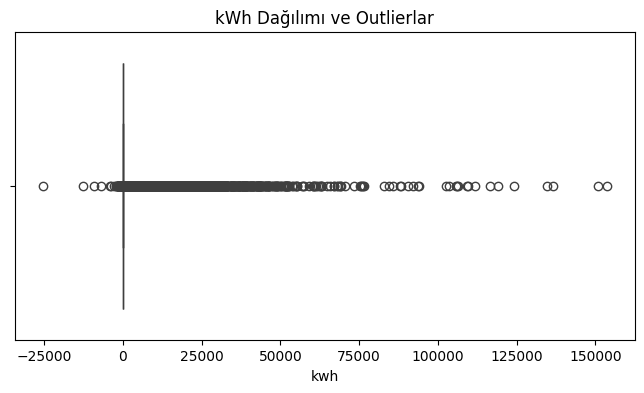

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_all["kwh"])
plt.title("kWh Dağılımı ve Outlierlar")
plt.show()

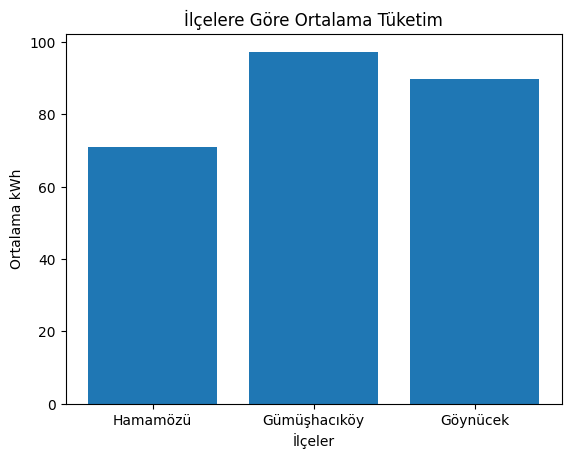

In [16]:
means = [
df_hamamozu["kwh"].mean(),
df_gumushacikoy["kwh"].mean(),
df_goyuncek["kwh"].mean()
]

labels = ["Hamamözü","Gümüşhacıköy","Göynücek"]

plt.bar(labels,means)

plt.title("İlçelere Göre Ortalama Tüketim")
plt.xlabel("İlçeler")
plt.ylabel("Ortalama kWh")

plt.show()

In [17]:
print(f"Ortalama Tüketim: {df_all['kwh'].mean():.2f}")
print(f"Medyan Tüketim: {df_all['kwh'].median():.2f}")

Ortalama Tüketim: 92.64
Medyan Tüketim: 46.62
